<a href="https://colab.research.google.com/github/tatsuya1232003-ctrl/Picard-LQG-Pantheon/blob/main/Singularity_Resolution%2C_Big_Bounce_Dynamics%2C_and_Time_Reflection_in_Picard_Loop_Quantum_Cosmology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:25: SyntaxWarning: invalid escape sequence '\i'
<>:25: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_1641/1320670056.py:25: SyntaxWarning: invalid escape sequence '\i'
  """C^\infty Smooth Picard Horn metric modulation function."""


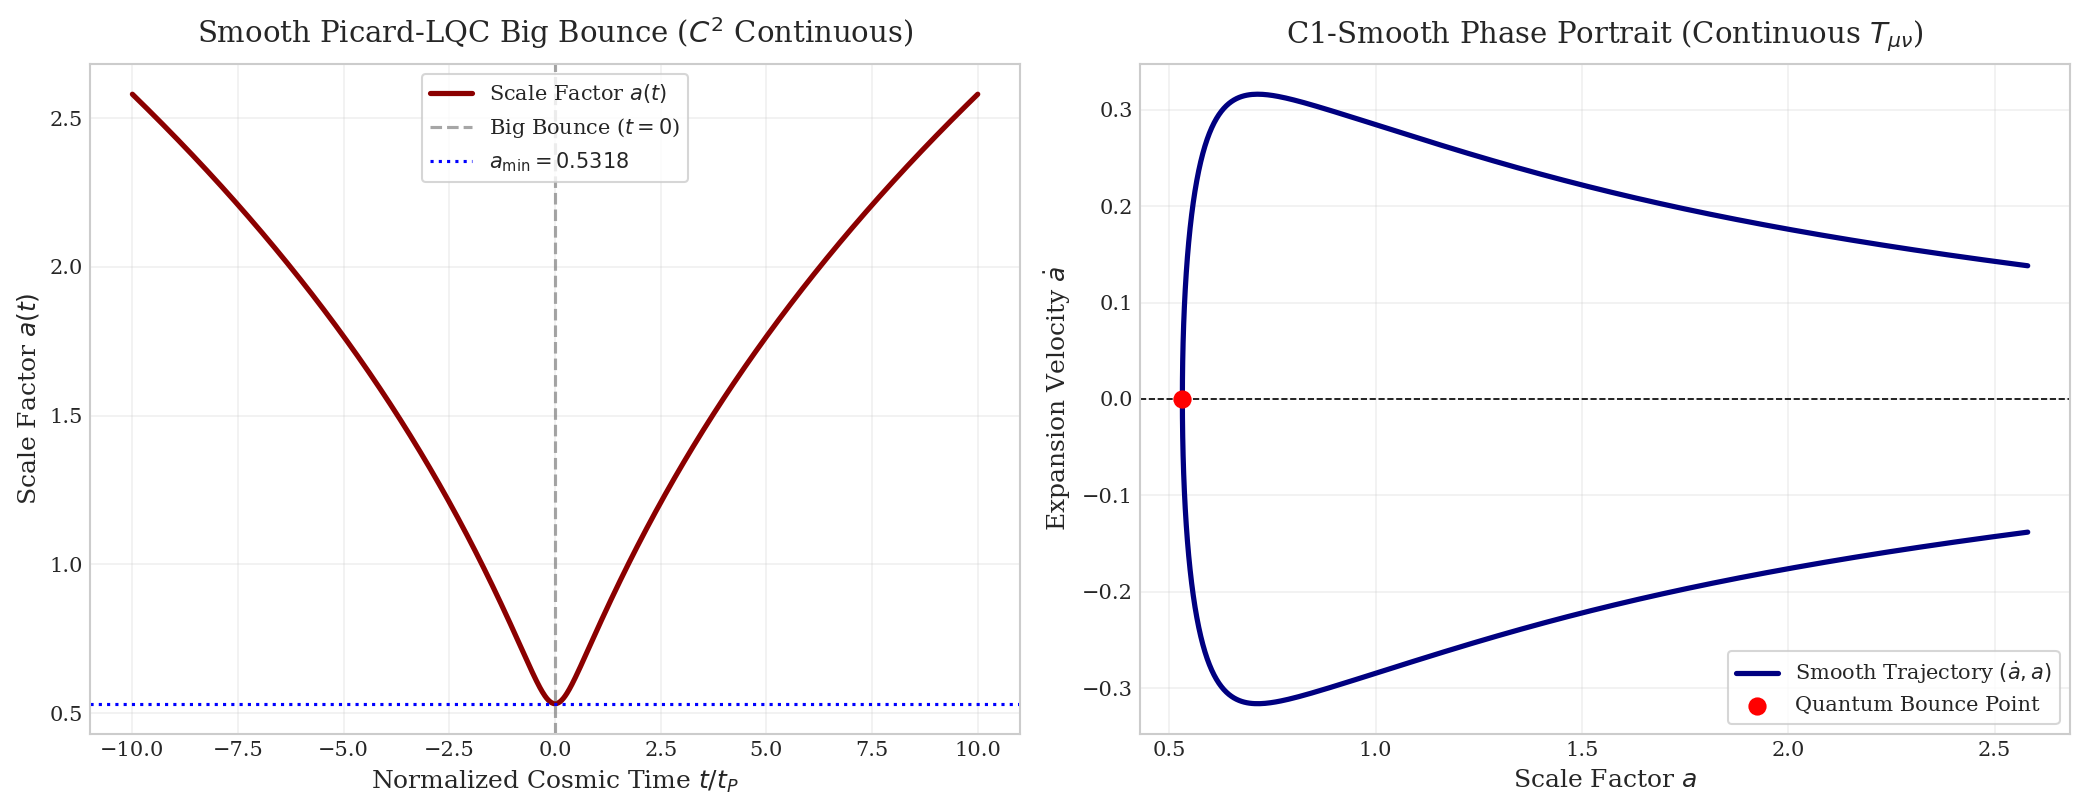

Successfully generated smooth C^2 plot and saved to: fig_picard_bounce_symmetric.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Matplotlib styling settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'serif'

# =====================================================================
# 1. PHYSICAL CONSTANTS & C^2-CONTINUOUS MODEL PARAMETERS
# =====================================================================
rho_crit = 1.0       # Planck critical density
rho_0 = 0.08          # Radiation density amplitude near bounce
alpha = 0.061         # Picard topological amplitude
z_c = 0.113           # Critical redshift
z_cut = 30.0          # Planckian effective cut-off scale
dz = 0.25             # INCREASED TRANSITION WIDTH: Ensures C^2 continuity of T_{\mu\nu}
c_light = 1.0         # Normalized speed of light
kappa = 1.0           # Normalized 8*pi*G/3

# =====================================================================
# 2. MODIFIED FRIEDMANN DYNAMICS (PICARD-LQC)
# =====================================================================
def f_picard(a):
    """C^\infty Smooth Picard Horn metric modulation function."""
    z = (1.0 / a) - 1.0
    z_clamp = np.clip(z, -0.99, 500.0)
    sigmoid = 1.0 / (1.0 + np.exp(-(z_clamp - z_c) / dz))
    return (1.0 + alpha * sigmoid) * np.exp(-z_clamp / z_cut)

def W_func(a):
    """Effective potential W(a) = (a * H)^2."""
    rho = rho_0 / (a**4)
    lqc_term = kappa * rho * (1.0 - rho / rho_crit)
    f_val = f_picard(a)
    curvature_term = (c_light**2) / ((a**2) * (f_val**2))
    return (a**2) * (lqc_term + curvature_term)

def dW_da(a, eps=1e-5):
    """Numerical derivative dW/da for second-order ODE integration."""
    return (W_func(a + eps) - W_func(a - eps)) / (2.0 * eps)

def system_ode(t, y):
    """Second-order ODE system for scale factor acceleration."""
    a, v = y
    da_dt = v
    dv_dt = 0.5 * dW_da(a)
    return [da_dt, dv_dt]

# =====================================================================
# 3. SYMMETRIC INTEGRATION AROUND t = 0 (BIG BOUNCE)
# =====================================================================
a_min = (rho_0 / rho_crit)**(0.25)
y0 = [a_min, 0.0]  # Exact bounce state at t = 0: a = a_min, \dot{a} = 0

t_eval_fwd = np.linspace(0.0, 10.0, 500)
t_eval_bwd = np.linspace(0.0, -10.0, 500)

sol_fwd = solve_ivp(system_ode, (0.0, 10.0), y0, t_eval=t_eval_fwd, method='DOP853', rtol=1e-9, atol=1e-11)
sol_bwd = solve_ivp(system_ode, (0.0, -10.0), y0, t_eval=t_eval_bwd, method='DOP853', rtol=1e-9, atol=1e-11)

# Combine backward (reversed) and forward solutions
t_sim = np.concatenate([sol_bwd.t[::-1], sol_fwd.t[1:]])
a_sim = np.concatenate([sol_bwd.y[0][::-1], sol_fwd.y[0][1:]])
v_sim = np.concatenate([sol_bwd.y[1][::-1], sol_fwd.y[1][1:]])

# Calculate continuous acceleration \ddot{a} (Proxy for continuous pressure P)
acc_sim = 0.5 * np.array([dW_da(a) for a in a_sim])

# =====================================================================
# 4. PLOTTING AND SAVING C^2-SMOOTH RESULTS
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# Plot 1: Symmetric Scale Factor Evolution a(t)
axes[0].plot(t_sim, a_sim, color='darkred', lw=2.5, label=r'Scale Factor $a(t)$')
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.7, label=r'Big Bounce ($t=0$)')
axes[0].axhline(a_min, color='blue', linestyle=':', label=r'$a_{\mathrm{min}} = ' + f'{a_min:.4f}' + r'$')
axes[0].set_xlabel(r'Normalized Cosmic Time $t / t_P$', fontsize=12)
axes[0].set_ylabel(r'Scale Factor $a(t)$', fontsize=12)
axes[0].set_title(r'Smooth Picard-LQC Big Bounce ($C^2$ Continuous)', fontsize=14, pad=10)
axes[0].legend(loc='upper center', frameon=True, fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: C^1-Continuous Phase Space Portrait (\dot{a} vs a)
axes[1].plot(a_sim, v_sim, color='navy', lw=2.5, label=r'Smooth Trajectory $(\dot{a}, a)$')
axes[1].scatter([a_min], [0], color='red', zorder=5, s=60, label=r'Quantum Bounce Point')
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_xlabel(r'Scale Factor $a$', fontsize=12)
axes[1].set_ylabel(r'Expansion Velocity $\dot{a}$', fontsize=12)
axes[1].set_title(r'C1-Smooth Phase Portrait (Continuous $T_{\mu\nu}$)', fontsize=14, pad=10)
axes[1].legend(loc='lower right', frameon=True, fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save image overwrite
output_filename = 'fig_picard_bounce_symmetric.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"Successfully generated smooth C^2 plot and saved to: {output_filename}")

# New Section